[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MarcoBattiato/PH6721-Deep-Learning-with-Python/blob/main/Classes/Class_5/05B-KernelsAndGaussianProcesses.ipynb)

# 05B — Kernels, Kernel Ridge Regression and Gaussian Processes

(by Marco Battiato. For questions/errors/bugs/typos report, please email at marco.battiato.teaching@gmail.com)

**PH6721 — Deep Learning with Python**

**Class 5, Notebook B — Hour 2**

**Instructor:** Marco Battiato (formerly Nanyang Assistant Professor @ Nanyang Technological University)

**email:**  marco.battiato.teaching@gmail.com

**In Person Classes:**  Wednesday 6:30pm - 9:45pm

**Consultation:** remote consultations are to be arranged by writing to marco.battiato.teaching@gmail.com

`05A` ended with a model that was honest about its own limits. The linear SVM scored 0.833 on the
telescope events while a random forest scored 0.935, and section 5 said why: the boundary is the
wrong *shape*, and no setting of `C` repairs a shape.

There has been a standing promise about this since Class 4. `04A` §11.2 said that the staircase a
tree builds around a curved boundary is an approximation to something else — *"a model whose
natural boundary was curved"* — and named Class 5's kernel methods as that model. This notebook
delivers it, and the mechanism is smaller than it sounds: `05A` §3.2 wrote a fitted SVM as a sum of
**dot products between samples**, and every dot product in that sum can be replaced by a different
measure of similarity. Nothing else changes. One argument in one call moves the telescope model
from the bottom of `05A`'s table to the top.

The same substitution works on ridge regression, and there it leads somewhere Class 2 could not
go. A **Gaussian process** returns the same curve as kernel ridge regression *and* an error bar on
every point of it — an uncertainty that comes from where you measured rather than from what you
measured. For an experimentalist deciding where to point an instrument next, that error bar is the
whole product.

## Learning Objectives

By the end of this notebook, students should be able to:

- explain why adding powers of a feature eventually fails — the usable degree is narrow, and the
  failure is global rather than local;
- fit a model in a basis of **one function per data point**, and say what that buys over a basis
  chosen in advance;
- explain why such a fit has as many coefficients as measurements, and must be penalised;
- say why the penalty is $\mathbf{a}^\top K \mathbf{a}$ rather than $\sum_i a_i^2$, in terms of the
  basis not being orthonormal;
- state the **kernel trick** — that $\mathbf{a}^\top K \mathbf{a}$ is $\lVert\mathbf{w}\rVert^2$ in
  a feature space nobody builds — and verify it for a polynomial kernel;
- say what makes a function an admissible kernel, and why a step window is not one;
- use the **RBF kernel**, recognise $\gamma$ as a flexibility dial alongside `C`, and explain why a
  kernel built from a distance makes **feature scaling** compulsory;
- apply the same substitution to ridge regression, giving **kernel ridge regression**;
- state that a **Gaussian process** posterior mean *is* kernel ridge regression, and verify it;
- explain why the GP's **predictive variance does not depend on the measured values**, and use it
  to decide where to measure next;
- say what kernel methods cost as the sample size grows, and name the standard remedies.

## Where this sits in the pipeline

One step, and it is step 5.3. A kernel is a **basis expansion** — the same idea `02A` §10 used to
fit a curve with a straight-line method — except that the expansion is never built. The box is
marked *now* and, by the end of section 2, it will be the only box in the course that the model
performs on your behalf.

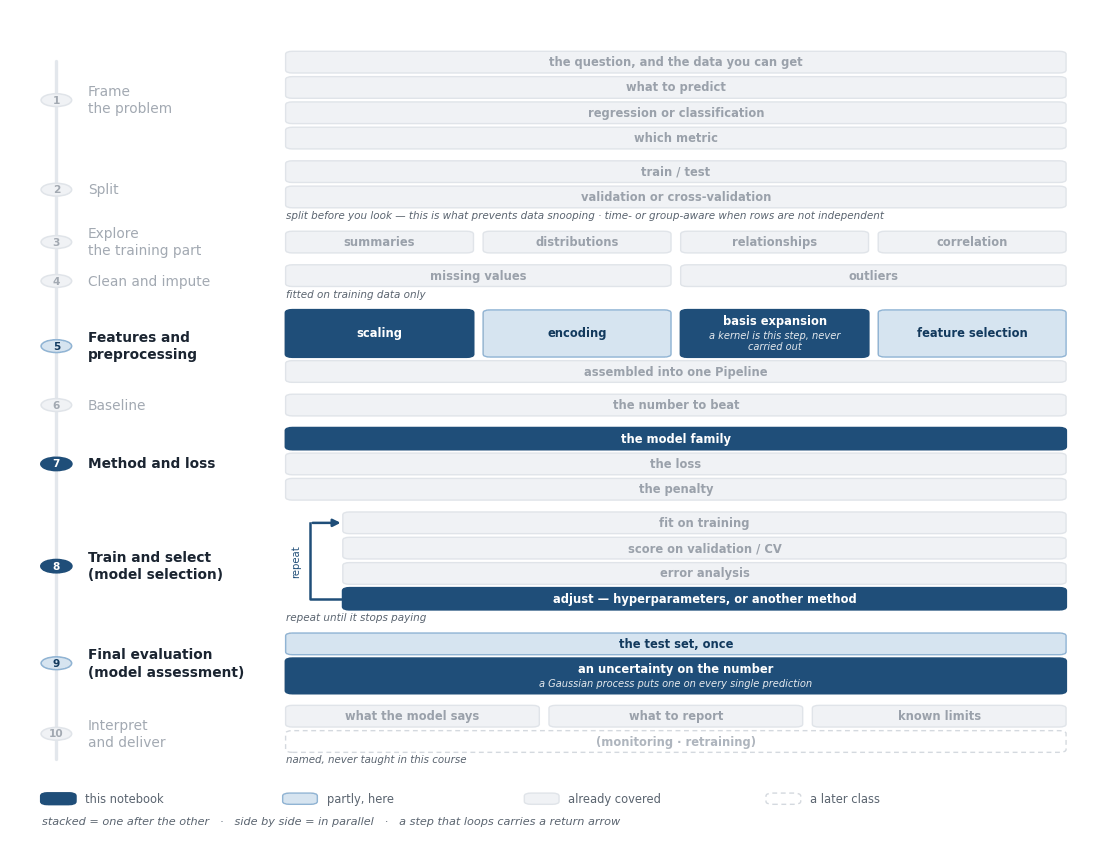

In [ ]:
# Infrastructure, not material. The map below is drawn by one helper file kept with
# the course; Colab has no copy of the repository, so fetch it when it is not already here.
import os, sys, urllib.request
import matplotlib.pyplot as plt

for folder in (".", "..", "../.."):
    if os.path.exists(f"{folder}/pipeline_map.py"):
        sys.path.insert(0, folder)
        break
else:
    urllib.request.urlretrieve("https://raw.githubusercontent.com/MarcoBattiato/"
                               "PH6721-Deep-Learning-with-Python/main/pipeline_map.py",
                               "pipeline_map.py")
from pipeline_map import pipeline_map

pipeline_map(
    {"1": "done", "2": "done", "3": "done", "4": "done", "5": "part", "5.1": "now",
     "5.3": "now", "5.after": "done", "6": "done", "7.1": "now", "7.2": "done",
     "7.3": "done", "8.1": "done", "8.2": "done", "8.3": "done", "8.4": "now",
     "9": "part", "9.2": "now", "10": "done"},
    notes={"5.3": "a kernel is this step, never carried out",
           "9.2": "a Gaussian process puts one on every single prediction"})
plt.show()

**Step 9.2 is the one to watch.** Every notebook so far has put an uncertainty on a *score* — a
fold spread, a bootstrap interval on the test RMSE. Section 5 puts one on each individual
**prediction**, which is a different object and answers a different question.

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.kernel_approximation import Nystroem, RBFSampler
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score

plt.rcParams.update({
    "figure.dpi": 110, "figure.autolayout": True, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "legend.fontsize": 11,
})

rng = np.random.default_rng(0)

# 1. A curve that a straight line cannot fit

`02A` fitted a spring at rest — hang a mass, measure the extension, recover the stiffness. Now let
go of it. The mass oscillates, the oscillation dies away, and a position sensor records the
displacement forty times over ten seconds to about a millimetre and a half.

Everything in this notebook comes out of trying to fit that one curve.

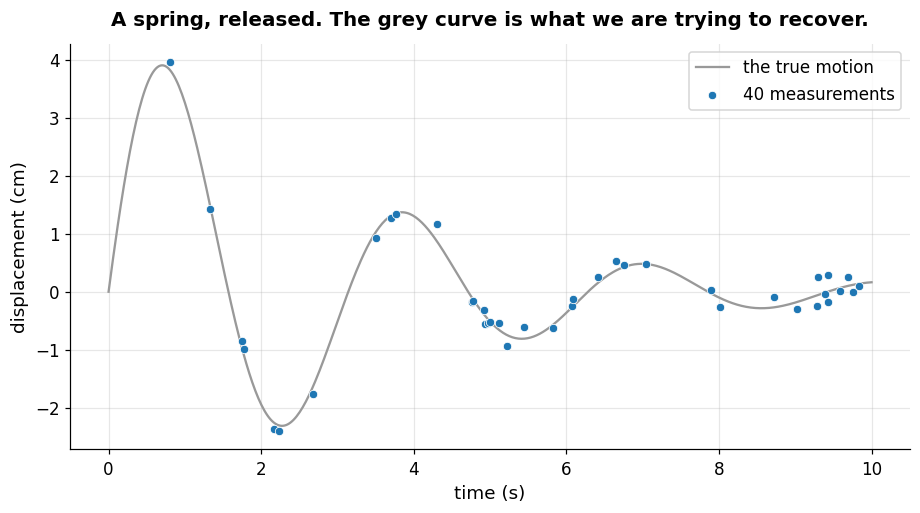

In [ ]:
amplitude, decay_time, frequency = 5.0, 3.0, 2.0          # cm, seconds, radians per second

def ringing(seconds):
    """Displacement of the damped mass on a spring, in cm."""
    return amplitude * np.exp(-seconds / decay_time) * np.sin(frequency * seconds)

spring_rng = np.random.default_rng(4)                      # this experiment's own seed
when = np.sort(spring_rng.uniform(0, 10, 40))              # when the sensor happened to read
measured = ringing(when) + spring_rng.normal(0, 0.15, when.size)   # 1.5 mm of measurement noise
smooth = np.linspace(0, 10, 500)                           # a fine grid, for drawing and scoring
inside = np.linspace(when.min(), when.max(), 400)          # only where measurements exist

rmse = lambda a, b: np.sqrt(np.mean((a - b) ** 2))
scaled = lambda s: s / 5.0 - 1.0        # powers of t behave badly unless t is centred on zero

plt.figure(figsize=(8.5, 4.8))
plt.plot(smooth, ringing(smooth), color="0.6", linewidth=1.5, label="the true motion")
plt.scatter(when, measured, s=30, color="tab:blue", zorder=3, edgecolor="white", linewidth=0.5,
            label=f"{when.size} measurements")
plt.xlabel("time (s)")
plt.ylabel("displacement (cm)")
plt.title("A spring, released. The grey curve is what we are trying to recover.")
plt.legend()
plt.show()

The grey curve is drawn only so that the figures can be read; in a real experiment it is precisely
what is unknown. A straight line through those points would be flat and useless — the displacement
starts positive, goes negative, comes back, and settles. One feature, and no linear model of it can
work.

## 1.1 Powers of the time

The move from `02A` §10 is to add features: not just $t$, but $t^2$, $t^3$, and so on. The model
stays linear in its coefficients and the fit stays least squares; only the columns change. It is a
Taylor expansion in all but name, and like a Taylor expansion the hope is that enough terms will
bend the curve into shape.

basis                          RMSE where measured  RMSE including the ends  largest coefficient
powers of t up to 1                          1.114                    1.356               0.0497
powers of t up to 5                          0.747                    2.318                 16.9
powers of t up to 9                          0.252                    7.495                  491
powers of t up to 13                         0.083                    0.685             2.94e+03
powers of t up to 19                         2.184                 1877.716             5.86e+05
powers of t up to 25                       148.668               704717.425             5.18e+08


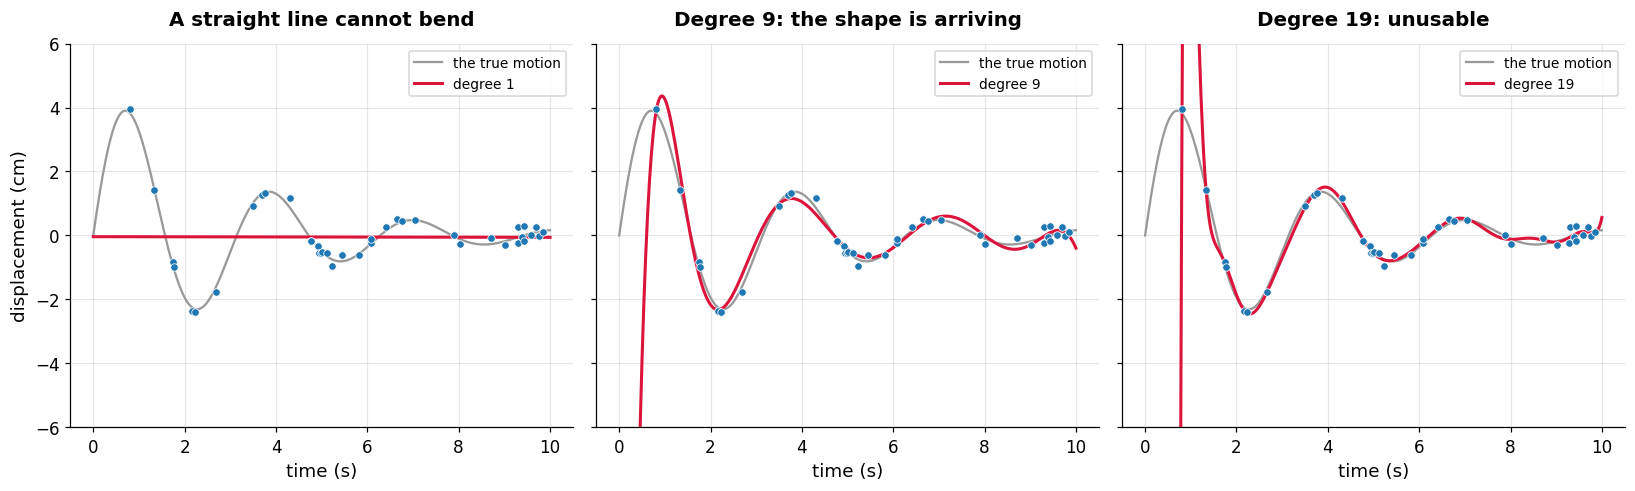

In [ ]:
print(f"{'basis':<28}{'RMSE where measured':>22}{'RMSE including the ends':>25}{'largest coefficient':>21}")
for degree in (1, 5, 9, 13, 19, 25):
    coefficients = np.polyfit(scaled(when), measured, degree)
    print(f"{'powers of t up to ' + str(degree):<28}"
          f"{rmse(np.polyval(coefficients, scaled(inside)), ringing(inside)):>22.3f}"
          f"{rmse(np.polyval(coefficients, scaled(smooth)), ringing(smooth)):>25.3f}"
          f"{np.abs(coefficients).max():>21.3g}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
for axis, degree, verdict in zip(axes, (1, 9, 19),
                                 ("A straight line cannot bend",
                                  "Degree 9: the shape is arriving",
                                  "Degree 19: unusable")):
    coefficients = np.polyfit(scaled(when), measured, degree)
    axis.plot(smooth, ringing(smooth), color="0.6", linewidth=1.5, label="the true motion")
    axis.scatter(when, measured, s=24, color="tab:blue", zorder=3, edgecolor="white", linewidth=0.5)
    axis.plot(smooth, np.polyval(coefficients, scaled(smooth)), color="crimson", linewidth=2,
              label=f"degree {degree}")
    axis.set(xlabel="time (s)", title=verdict)
    axis.legend(loc="upper right", fontsize=9)
axes[0].set(ylabel="displacement (cm)", ylim=(-6, 6))
plt.show()

Read the two columns separately, because they say different things.

**Where the measurements are**, powers of $t$ do eventually work: degree 13 reaches 0.083 cm, which
is better than the 0.15 cm noise on each reading. So it is not true that a polynomial cannot fit
this curve.

**But the good degree is a knife-edge.** Degree 9 is three times worse, degree 19 is twenty-six
times worse, and degree 25 misses by 149 cm on a 5 cm oscillation. Nothing about the data tells you
that 13 is the number; you would have to search for it, and the penalty for overshooting is total.

**And the failure is global.** Look at the third panel, and at the second column of the table. Every
power of $t$ is non-zero everywhere, so the coefficients are shared across the whole domain: what
the fit does in the last second is tied to what it does in the first. Degree 19 misses by 1878 cm
once the empty ends of the domain are included. A basis of powers has no notion of *here*.

There is a third problem that this one-dimensional example cannot show. With $p$ features rather
than one, the number of terms up to degree $d$ explodes — ten features give 66 quadratic terms and
286 cubic ones, and a hundred features give 5050 quadratic terms. Choosing which of them to keep is
the subject of the optional notebook `X1`, and it is not a happy one.

## 1.2 A basis that follows the measurements

So change the basis. Instead of functions that are non-zero everywhere, use one that is large near
a chosen point and dies away from it — and put one at **each measurement**:

$$
f_i(t) \;=\; \exp\!\Big(-\big((t - t_i)/w\big)^2\Big),
\qquad\qquad
f(t) \;=\; \sum_{i=1}^{n} a_i\, f_i(t) .
$$

Forty measurements, forty bumps, forty coefficients. The width $w$ says how far each measurement is
allowed to speak; everything else is fitted exactly as before, by least squares.

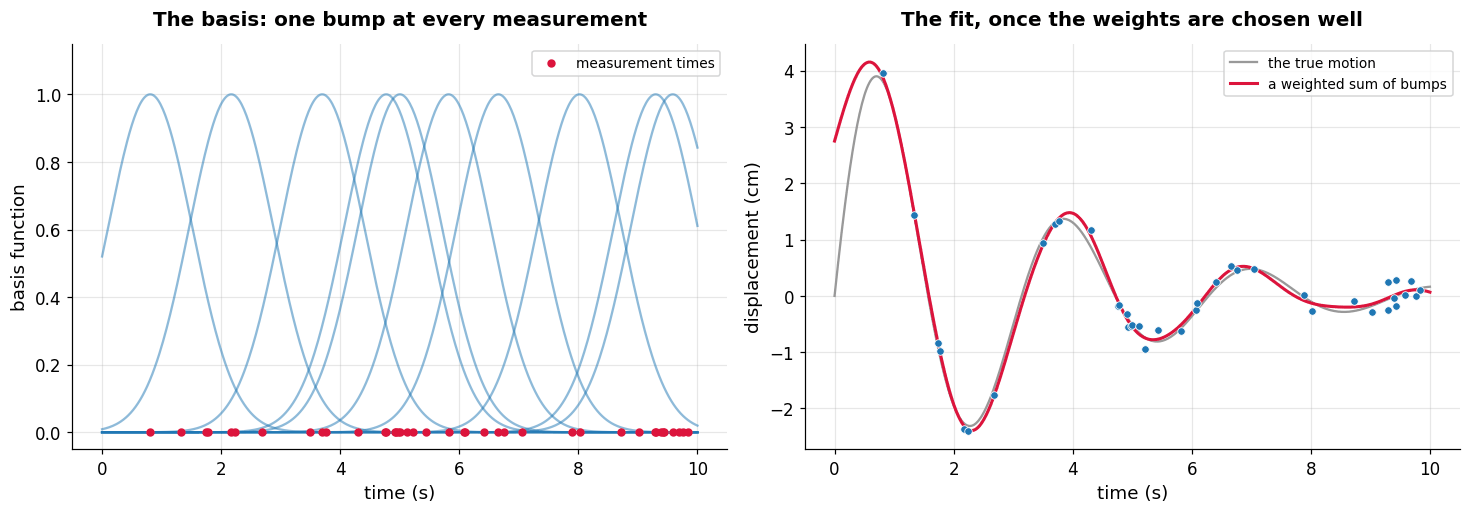

In [ ]:
width = 1.0

def bumps(at, centres):
    """One Gaussian bump of width `width` centred on each entry of `centres`, evaluated at `at`."""
    return np.exp(-((at[:, None] - centres[None, :]) / width) ** 2)

K = bumps(when, when)                       # bump j evaluated at measurement i
K_smooth = bumps(smooth, when)
K_inside = bumps(inside, when)

fitted = np.linalg.solve(K + 0.01 * np.eye(when.size), measured)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))   # separate y axes: one panel is the basis, one the fit
for centre in when[::4]:                    # a few of the forty, to show what they look like
    axes[0].plot(smooth, np.exp(-((smooth - centre) / width) ** 2), color="tab:blue", alpha=0.5)
axes[0].scatter(when, np.zeros_like(when), s=20, color="crimson", zorder=3, label="measurement times")
axes[0].set(xlabel="time (s)", ylabel="basis function", ylim=(-0.05, 1.15),
            title="The basis: one bump at every measurement")
axes[0].legend(loc="upper right", fontsize=9)

axes[1].plot(smooth, ringing(smooth), color="0.6", linewidth=1.5, label="the true motion")
axes[1].scatter(when, measured, s=24, color="tab:blue", zorder=3, edgecolor="white", linewidth=0.5)
axes[1].plot(smooth, K_smooth @ fitted, color="crimson", linewidth=2, label="a weighted sum of bumps")
axes[1].set(xlabel="time (s)", ylabel="displacement (cm)",
            title="The fit, once the weights are chosen well")
axes[1].legend(loc="upper right", fontsize=9)
plt.show()

That is the whole idea, and it is worth saying plainly what changed. The model is still **linear in
its coefficients** and still fitted by least squares. Only the basis moved: from functions of $t$
chosen in advance, to functions of the **distance to each measurement**. The basis is no longer
something you invent; it is handed to you by the data.

## 1.3 Forty coefficients and forty measurements

Which raises the obvious objection. There are as many coefficients as there are readings, so the
fit can pass through every point exactly, noise and all. It should be a disaster, and it is.

In [ ]:
print(f"{'':30}{'RMSE where measured':>22}{'RMSE including the ends':>25}{'largest weight':>17}")
for penalty in (0.0, 1e-6, 1e-3, 1e-2, 1e-1, 1.0):
    weights = np.linalg.solve(K + penalty * np.eye(when.size), measured)
    label = "no penalty at all" if penalty == 0 else f"penalty = {penalty:g}"
    print(f"{label:<30}{rmse(K_inside @ weights, ringing(inside)):>22.3f}"
          f"{rmse(K_smooth @ weights, ringing(smooth)):>25.3f}{np.abs(weights).max():>17.3g}")

                                 RMSE where measured  RMSE including the ends   largest weight
no penalty at all                           3683.122               225624.685         2.75e+15
penalty = 1e-06                                0.161                    1.009         3.01e+05
penalty = 0.001                                0.091                    0.471              301
penalty = 0.01                                 0.090                    0.387             28.7
penalty = 0.1                                  0.087                    0.261             4.29
penalty = 1                                    0.412                    0.550             1.98


With no penalty the fit misses the truth by 3683 cm inside the measured region, using weights of
order $10^{15}$ to thread every point. It is the clearest overfitting in the course. Add a small
penalty and the same basis gives 0.090 cm — as good as the best polynomial, found without searching
for a magic degree, and 0.387 cm across the whole domain against that polynomial's 0.685.

So the basis is not the problem. The problem is that nothing yet stops it being used to its limit.

## 1.4 Which penalty?

The obvious thing to write down is a ridge penalty on the coefficients,
$\lambda \sum_i a_i^2$, exactly as `03C` §2 did. The one the literature uses instead is

$$
\lambda \sum_i \sum_j a_i a_j K_{ij} \;=\; \lambda\, \mathbf{a}^\top K \mathbf{a},
\qquad\text{where } K_{ij} = f_j(t_i),
$$

which looks gratuitously complicated. The next cell fits both, at their own best $\lambda$, at two
bump widths.

In [ ]:
def best_fit(kind, K_fit, K_score, target):
    """Sweep the penalty and return the best score this penalty shape can reach."""
    n = len(K_fit)
    scores = []
    for penalty in np.logspace(-12, 3, 400):
        if kind == "a^T K a":                              # the usual choice
            weights = np.linalg.solve(K_fit + penalty * np.eye(n), measured)
        else:                                              # the obvious choice
            weights = np.linalg.solve(K_fit @ K_fit + penalty * np.eye(n), K_fit @ measured)
        scores.append(rmse(K_score @ weights, target))
    return min(scores)

print(f"{'bump width':>12}{'penalty on sum a_i^2':>24}{'penalty on a^T K a':>22}")
for w in (1.0, 7.0):
    width = w
    K_fit, K_score = bumps(when, when), bumps(inside, when)
    naive = best_fit("sum a^2", K_fit, K_score, ringing(inside))
    proper = best_fit("a^T K a", K_fit, K_score, ringing(inside))
    print(f"{w:>12.1f}{naive:>24.3f}{proper:>22.3f}")
width = 1.0                                                 # restore the sensible width

  bump width    penalty on sum a_i^2    penalty on a^T K a
         1.0                   0.079                 0.082
         7.0                   0.594                 0.111


At a width of 1 second — bumps about as narrow as the features being fitted — the two penalties are
indistinguishable. At a width of 7 seconds, wider than the whole oscillation, the obvious penalty
is several times worse.

The reason is the one thing in this notebook worth memorising. $\sum_i a_i^2$ is the formula for the
squared length of a vector **in an orthonormal basis**, and these bumps are nothing of the kind:
neighbouring ones overlap heavily, and wide ones are nearly identical to each other. In a basis
whose functions have inner products $K_{ij}$, the squared length of $\sum_i a_i f_i$ is
$\mathbf{a}^\top K \mathbf{a}$, which is ordinary linear algebra rather than a machine-learning
trick.

When the bumps are narrow they are nearly orthogonal, $K$ is nearly the identity, and the two agree.
When they are wide the basis is badly redundant and only the correct formula survives. Building a
feature narrower than your bumps needs enormous, nearly cancelling coefficients, and
$\mathbf{a}^\top K \mathbf{a}$ charges almost nothing for them while $\sum_i a_i^2$ forbids them.

> **A penalty is a length, and a length needs a metric.** $\sum_i a_i^2$ measures the *numbers*;
> $\mathbf{a}^\top K \mathbf{a}$ measures the *function*. They agree only when the basis is
> orthonormal, which a basis of overlapping bumps never is.

# 2. What you have just built is a kernel method

Nothing in section 1 mentioned kernels. A basis of bumps was chosen, coefficients were fitted by
least squares, and a penalty was written down correctly. That is the whole of kernel regression, and
the vocabulary can now be attached to parts you have already used.

The matrix $K$, whose entries are the basis functions evaluated at the measurement points, is the
**kernel matrix**. The function behind it,
$K(t, t') = \exp(-((t-t')/w)^2)$, is the **kernel** — and written with $\gamma = 1/w^2$ it is the
**radial basis function** kernel that the rest of the course will use. The penalty
$\mathbf{a}^\top K \mathbf{a}$ is the squared length of the fitted function.

## 2.1 The penalty is a length in a space you never built

One fact turns this from a convenient recipe into a method, and it is the only piece of algebra in
the section. Suppose the kernel can be written as a dot product of *feature vectors*,

$$
K(\mathbf{x}, \mathbf{x}') \;=\; \boldsymbol{\phi}(\mathbf{x}) \cdot \boldsymbol{\phi}(\mathbf{x}') ,
$$

for some map $\boldsymbol{\phi}$ into a possibly enormous space. Then the fitted function is a plain
linear model in that space, $f(\mathbf{x}) = \mathbf{w}\cdot\boldsymbol{\phi}(\mathbf{x})$, with
$\mathbf{w} = \sum_i a_i \boldsymbol{\phi}(\mathbf{x}_i)$, and its squared length is

$$
\lVert\mathbf{w}\rVert^2 \;=\; \sum_i\sum_j a_i a_j\, \boldsymbol{\phi}(\mathbf{x}_i)\cdot
\boldsymbol{\phi}(\mathbf{x}_j) \;=\; \sum_i\sum_j a_i a_j K_{ij} \;=\; \mathbf{a}^\top K \mathbf{a} .
$$

The penalty that section 1.4 arrived at by linear algebra is therefore an **ordinary ridge penalty
on an ordinary linear model** — just one living in a space of features nobody constructed. That is
why `C` in an SVM, $\lambda$ in this fit, and the noise level in section 5 all turn out to be the
same number in different clothing.

The cell below takes the degree-2 polynomial kernel, $(1 + \mathbf{x}\cdot\mathbf{x}')^2$, where
$\boldsymbol{\phi}$ is short enough to write down, and checks both halves of the claim.

In [ ]:
def expansion(x):
    """Every polynomial term up to degree 2, for a sample with two features."""
    return np.array([1, np.sqrt(2) * x[0], np.sqrt(2) * x[1],
                     x[0] ** 2, np.sqrt(2) * x[0] * x[1], x[1] ** 2])

pair = rng.normal(size=(2, 2))
built = expansion(pair[0]) @ expansion(pair[1])        # build the six features, then dot them
from_kernel = (1 + pair[0] @ pair[1]) ** 2             # never build them
print(f"phi(x) . phi(x')      : {built:.12f}")
print(f"(1 + x . x')^2        : {from_kernel:.12f}")
print(f"difference            : {abs(built - from_kernel):.1e}")

sample = rng.normal(size=(6, 2))
K_poly = (1 + sample @ sample.T) ** 2
Phi = np.array([expansion(x) for x in sample])
print(f"\nis K the matrix of dot products of the expansions?  "
      f"max difference {np.abs(K_poly - Phi @ Phi.T).max():.1e}")
coefficients = rng.normal(size=6)
w = Phi.T @ coefficients
print(f"||w||^2 in the six-dimensional space : {w @ w:.10f}")
print(f"a^T K a                              : {coefficients @ K_poly @ coefficients:.10f}")

phi(x) . phi(x')      : 1.137769242607
(1 + x . x')^2        : 1.137769242607
difference            : 0.0e+00

is K the matrix of dot products of the expansions?  max difference 7.1e-15
||w||^2 in the six-dimensional space : 28.9954820663
a^T K a                              : 28.9954820663


Both hold exactly. The kernel returns the dot product of two six-dimensional expansions without
building either, and the penalty of section 1.4 is the squared length of the weight vector in that
space.

This is the **kernel trick**, and it is worth being clear about what it is and is not. It is a
statement that a certain computation can be skipped. It is *not* the source of the flexibility —
that came from using one basis function per measurement, back in section 1.2, and would have been
there whether or not anyone noticed the feature space.

Where it earns its keep is the case where $\boldsymbol{\phi}$ cannot be written down at all. The
bumps of section 1 correspond to an **infinite-dimensional** $\boldsymbol{\phi}$: there is no list
of columns to build, at any price, and the kernel is the only access to that space. The polynomial
kernel, by contrast, saves effort and nothing more — its expansion is finite, and you could always
have built it by hand.

## 2.2 Not every function will do

Since $K$ has to be a matrix of dot products, it cannot be arbitrary. It must be **symmetric**, and
**positive semi-definite**: for any set of points, the matrix $K_{ij}$ must have no negative
eigenvalues. Those are exactly the functions that correspond to a dot product in some feature space.

This is not a formality, and the obvious naive choice fails it. `05A` §2 predicted from the
neighbours inside a fixed radius, which is the same sum with a **step** in place of the bump —
$K(t, t') = 1$ if the two are within $r$ of each other and $0$ otherwise.

In [ ]:
points = rng.uniform(0, 10, 60)[:, None]
gaps = np.abs(points - points.T)

print(f"{'window':<34}{'smallest eigenvalue of K':>26}")
for radius in (0.5, 1.5, 3.0):
    step_K = (gaps < radius).astype(float)
    print(f"{'step, everything within ' + str(radius):<34}"
          f"{np.linalg.eigvalsh(step_K).min():>26.3f}")
for w in (0.5, 1.5, 3.0):
    print(f"{'smooth bump of width ' + str(w):<34}"
          f"{np.linalg.eigvalsh(np.exp(-(gaps / w) ** 2)).min():>26.3e}")

window                              smallest eigenvalue of K
step, everything within 0.5                           -1.772
step, everything within 1.5                           -4.173
step, everything within 3.0                           -6.343
smooth bump of width 0.5                           8.748e-16
smooth bump of width 1.5                          -2.875e-15
smooth bump of width 3.0                          -5.779e-15


The step window has strongly negative eigenvalues; the smooth bump does not. So averaging over a
fixed radius is a perfectly good thing to do — it is what `05A` §2 did, and it worked — but it
cannot be given **fitted** weights, because there is no feature space behind it, no
$\lVert\mathbf{w}\rVert^2$ to penalise, and no convex problem to solve. Smoothing the window is what
makes the step from averaging to fitting legal.

## 2.3 The two kernels in use

In practice you will not invent one. Two cover almost everything:

| kernel | formula | the expansion behind it |
|---|---|---|
| **polynomial**, degree $d$ | $(1 + \mathbf{x}\cdot\mathbf{x}')^d$ | every product of features up to degree $d$ — finite |
| **radial basis function (RBF)** | $\exp(-\gamma\lVert \mathbf{x}-\mathbf{x}'\rVert^2)$ | infinitely many dimensions |

The RBF kernel is section 1's bump, written with $\gamma = 1/w^2$ and with the one-dimensional
distance $|t - t'|$ replaced by the Euclidean distance of `05A` §1. It turns a distance into a
**similarity**: 1 when two samples coincide, falling smoothly to 0 as they separate. $\gamma$ is the
width dial of section 1.4, inverted — large $\gamma$ is a narrow bump.

# 3. The same trick, for a boundary

Everything so far fitted a number. The step to classification needs no new machinery at all: the
`05A` support vector machine also touches its samples only through dot products, so the same
substitution applies to it unchanged.

`02B` §9 built two classes as concentric rings — one in a central disc, the other in a ring around
it — and fitted a logistic regression. The result was the sharpest failure in the course: the model
did not draw a bad line, it found that **no** line helps, set both coefficients to within a few
hundredths of zero, and predicted a single class everywhere. The rings are rebuilt below, with
three flat-boundary models and one tree.

In [ ]:
rings_rng = np.random.default_rng(0)                    # same construction, and same seed, as 02B section 9
n_points = 300
radius = rings_rng.uniform(0, 1, n_points)
angle = rings_rng.uniform(0, 2 * np.pi, n_points)

X_rings = np.column_stack([radius * np.cos(angle), radius * np.sin(angle)])
y_rings = (radius < 0.5).astype(int)                    # inner disc is class 1

contenders = [("logistic regression (02B)", LogisticRegression()),
              ("linear SVM (05A)", SVC(kernel="linear")),
              ("decision tree, depth 5 (04A)", DecisionTreeClassifier(max_depth=5, random_state=0))]

print(f"{'':30}{'training accuracy':>19}")
for name, model in contenders:
    print(f"{name:30}{model.fit(X_rings, y_rings).score(X_rings, y_rings):>19.3f}")
print(f"\nmajority class alone: {max(y_rings.mean(), 1 - y_rings.mean()):.3f}")

                                training accuracy
logistic regression (02B)                   0.550
linear SVM (05A)                            0.550
decision tree, depth 5 (04A)                0.980

majority class alone: 0.550


The two flat boundaries score 0.550, exactly the majority class — they have learned nothing. The
tree reaches 0.980 by stacking axis-aligned cuts into a staircase, which is `04A` §11.2's picture,
and `04A` §11.2 promised that the staircase is an approximation to a model whose boundary is
genuinely curved. That model is one argument away.

## 3.1 The rings, solved

`SVC(kernel="linear")` becomes `SVC()`, whose default kernel is RBF. Nothing else changes.

SVM, linear kernel : 0.550
SVM, RBF kernel    : 0.987
support vectors    : 68 of 300


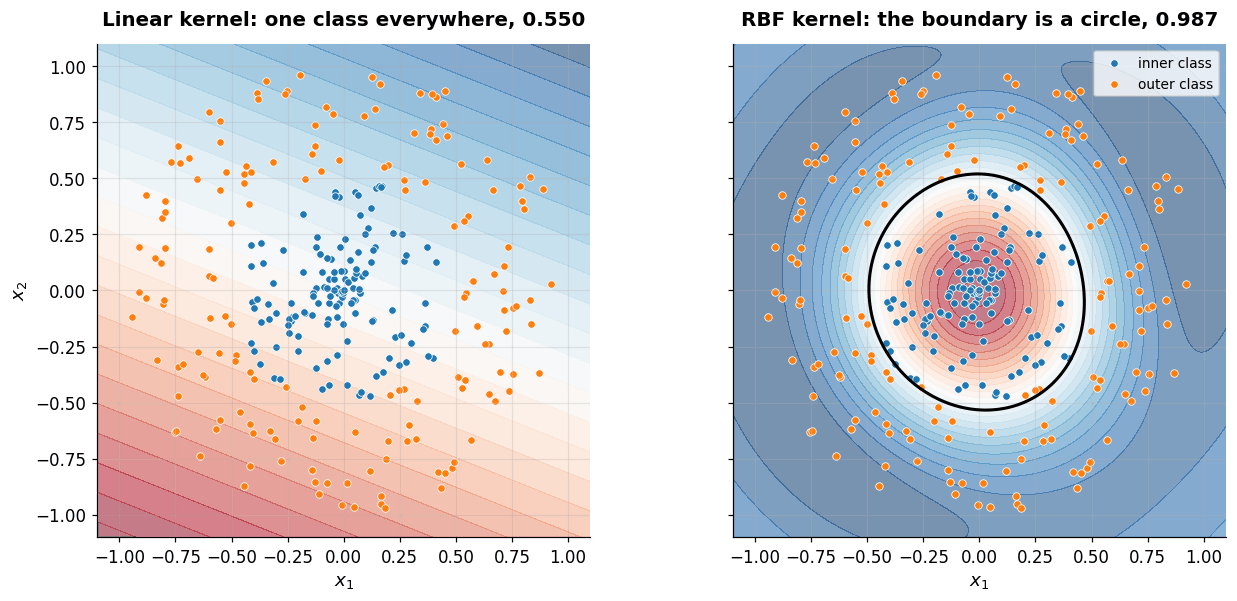

In [ ]:
rings_rbf = SVC().fit(X_rings, y_rings)                       # kernel="rbf" is the default
rings_linear = SVC(kernel="linear").fit(X_rings, y_rings)

print(f"SVM, linear kernel : {rings_linear.score(X_rings, y_rings):.3f}")
print(f"SVM, RBF kernel    : {rings_rbf.score(X_rings, y_rings):.3f}")
print(f"support vectors    : {rings_rbf.n_support_.sum()} of {n_points}")

mesh_x, mesh_y = np.meshgrid(np.linspace(-1.1, 1.1, 300), np.linspace(-1.1, 1.1, 300))
mesh = np.column_stack([mesh_x.ravel(), mesh_y.ravel()])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.6), sharey=True)
for axis, model, title in [(axes[0], rings_linear, "Linear kernel: one class everywhere, 0.550"),
                           (axes[1], rings_rbf, "RBF kernel: the boundary is a circle, 0.987")]:
    scores = model.decision_function(mesh).reshape(mesh_x.shape)
    axis.contourf(mesh_x, mesh_y, scores, levels=25, cmap="RdBu_r", alpha=0.55)
    axis.contour(mesh_x, mesh_y, scores, levels=[0], colors="black", linewidths=2)
    for value, name in [(1, "inner class"), (0, "outer class")]:
        mask = y_rings == value
        axis.scatter(X_rings[mask, 0], X_rings[mask, 1], s=24, edgecolor="white",
                     linewidth=0.5, label=name)
    axis.set(xlabel="$x_1$", title=title)
    axis.set_aspect("equal")
axes[0].set_ylabel("$x_2$")
axes[1].legend(loc="upper right", fontsize=9)
plt.show()

0.987 — against 0.550 for the same machine with a flat boundary, and 0.980 for the tree's
staircase. Nobody told the model that the classes were arranged in rings, and
no expanded design matrix was ever constructed.

This is `04A` §11.2's promise discharged. The tree reached 0.980 by cutting a staircase; the RBF
SVM reaches 0.987 with a boundary that is simply round, because round is what the data are.

## 3.2 $\gamma$ and `C` are two dials, and one of them overfits fast

The next cell sweeps $\gamma$ over four orders of magnitude on 4,000 telescope events, holding
`C` fixed, and reports the training ROC AUC beside the cross-validated one.

1. Which way will the **training** score move as $\gamma$ grows?
2. Which way will the **cross-validated** score move?
3. The number of support vectors is printed too. `05A` §3.4 found that samples inside the margin
   are support vectors — so what should that count do at the two ends of the sweep?

**Think about your answer before running this cell.**

In [ ]:
magic = fetch_openml(data_id=1120, as_frame=True, parser="auto")
X_magic = magic.data.rename(columns=lambda name: name.rstrip(":"))   # OpenML's names end in ":"
y_magic = (magic.target == "g").astype(int)                          # 1 = gamma, 0 = hadron

X_train, X_test, y_train, y_test = train_test_split(X_magic, y_magic, test_size=0.25,
                                                    random_state=0, stratify=y_magic)
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

subset = slice(0, 4000)                       # a quarter of the training events, to keep this quick
print(f"{'gamma':>8}{'training ROC AUC':>19}{'cross-validated':>18}{'support vectors':>18}")
for gamma_value in [0.001, 0.01, 0.1, 1.0, 10.0]:
    machine = make_pipeline(StandardScaler(), SVC(gamma=gamma_value, C=10))
    validated = cross_val_score(machine, X_train[subset], y_train[subset], cv=folds,
                                scoring="roc_auc", n_jobs=-1)
    machine.fit(X_train[subset], y_train[subset])
    trained = roc_auc_score(y_train[subset], machine.decision_function(X_train[subset]))
    print(f"{gamma_value:>8}{trained:>19.4f}{validated.mean():>18.4f}{machine[-1].n_support_.sum():>18}")

The output, since it is not stored in the notebook: the training score climbs from 0.8535 at
$\gamma = 0.001$ to **1.0000** at $\gamma = 10$ — a perfect score on its own training events. The
cross-validated score does something quite different. It rises to 0.9105 at $\gamma = 0.1$ and
then **falls back to 0.8142**, worse than the linear SVM of `05A`. The support-vector count traces
a U: 2028 at the stiffest setting, 1376 at the best one, and 3998 at the loosest — which is every
one of the 4,000 events, each one carrying its own little bump.

This is the bias–variance picture of `03B` in its purest form, and the gap between the two columns
is the diagnosis: a training score of 1.0000 beside a cross-validated 0.8142 is a model that has
memorised. `05A`'s `C` sweep could not produce this, because a straight line has too little
freedom to memorise anything. With a kernel, the model has as much freedom as you ask for.

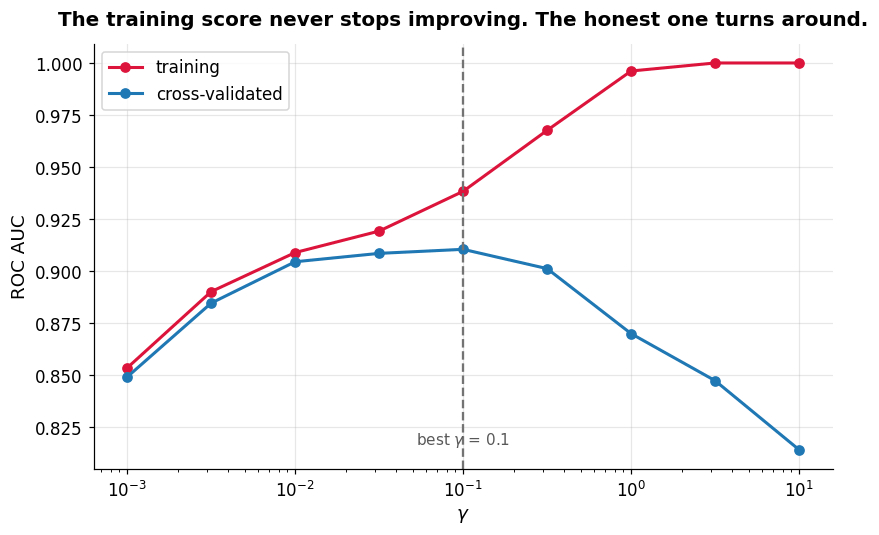

In [ ]:
gammas = np.logspace(-3, 1, 9)
train_curve, validated_curve = [], []
for gamma_value in gammas:
    machine = make_pipeline(StandardScaler(), SVC(gamma=gamma_value, C=10))
    validated_curve.append(cross_val_score(machine, X_train[subset], y_train[subset], cv=folds,
                                           scoring="roc_auc", n_jobs=-1).mean())
    machine.fit(X_train[subset], y_train[subset])
    train_curve.append(roc_auc_score(y_train[subset], machine.decision_function(X_train[subset])))

best = gammas[int(np.argmax(validated_curve))]
plt.figure(figsize=(7.8, 5))
plt.semilogx(gammas, train_curve, "o-", color="crimson", linewidth=2, label="training")
plt.semilogx(gammas, validated_curve, "o-", color="tab:blue", linewidth=2, label="cross-validated")
plt.axvline(best, color="0.45", linestyle="--", linewidth=1.5)
plt.annotate(f"best $\\gamma$ = {best:.3g}", xy=(best, min(validated_curve)), fontsize=10,
             color="0.35", ha="center", va="bottom")
plt.xlabel("$\\gamma$")
plt.ylabel("ROC AUC")
plt.title("The training score never stops improving. The honest one turns around.")
plt.legend()
plt.show()

## 3.3 Back to the telescope

`05A` §4.1 left a table with three tiers on these events: the two flat-boundary models at 0.833
and 0.837, nearest neighbours at 0.900, and the tree ensembles at about 0.935. The linear SVM was
at the bottom. Refit it on the full training set with an RBF kernel and a tuned `C`.

In [ ]:
print(f"{'':44}{'cross-validated ROC AUC':>26}")
for name, machine in [("linear SVM, C = 1 (05A section 4.1)", SVC(kernel="linear", C=1)),
                      ("RBF kernel, default C = 1", SVC()),
                      ("RBF kernel, C = 10", SVC(C=10))]:
    scores = cross_val_score(make_pipeline(StandardScaler(), machine), X_train, y_train,
                             cv=folds, scoring="roc_auc", n_jobs=-1)
    print(f"{name:44}{scores.mean():>20.4f} +/- {scores.std():.4f}")

print("\nfor reference, from 05A section 4.1:")
print(f"{'31 nearest neighbours':44}{0.900:>20.4f}")
print(f"{'random forest, 300 trees (04B)':44}{0.935:>20.4f}")

                                               cross-validated ROC AUC


linear SVM, C = 1 (05A section 4.1)                       0.8328 +/- 0.0056


RBF kernel, default C = 1                                 0.9154 +/- 0.0041


RBF kernel, C = 10                                        0.9236 +/- 0.0049

for reference, from 05A section 4.1:
31 nearest neighbours                                     0.9000
random forest, 300 trees (04B)                            0.9350


0.8328 to 0.9236. One argument, and the SVM has crossed two tiers of `05A`'s table: past nearest
neighbours at 0.900 and within 0.012 of the random forest, which is the strongest model the course
has fitted to these events. The boundary really was the problem, exactly as `05A` §5 diagnosed,
and `C` really could not fix it.

**A caution, and it is the honest half of the result.** This is the best-case advertisement for
kernels: ten continuous features on a common physical footing, 14,265 events, and a genuinely
curved boundary. Section 6 shows what the same model costs at ten times the sample size, and
broad benchmarks place the two families closer than this single table suggests: across a hundred
or so datasets, random forests come out the strongest family overall, with RBF-kernel SVMs
immediately behind them.

## 3.4 A kernel built from a distance must be given scaled features

`05A` §1 showed that an unscaled Euclidean distance on these events is dominated by four
millimetre-valued features, while three others — including the total light — contribute less than
0.01% of it. The RBF kernel has that same distance inside it, so it inherits that same defect, and
`StandardScaler` is not an optional tidiness.

In [ ]:
for label, machine in [("RBF kernel, raw features", SVC(C=10)),
                       ("RBF kernel, inside a StandardScaler", make_pipeline(StandardScaler(), SVC(C=10)))]:
    scores = cross_val_score(machine, X_train, y_train, cv=folds, scoring="roc_auc", n_jobs=-1)
    print(f"{label:38}{scores.mean():>10.4f} +/- {scores.std():.4f}")

RBF kernel, raw features                  0.8835 +/- 0.0047


RBF kernel, inside a StandardScaler       0.9236 +/- 0.0049


0.8835 unscaled against 0.9236 scaled — four hundredths of ROC AUC thrown away by a missing step,
with no error and no warning. It is `05A` §1's lesson again, and the reason it has to be repeated
is that the kernel hides the distance: nothing in `SVC(C=10)` looks like it is measuring one.

> Any method with a distance inside it needs its features scaled, and a kernel is a distance in
> disguise. The scaler goes inside the pipeline, so that each fold's scaling is fitted on that
> fold's training part only — `02C` §6.3.

# 4. The same substitution, for regression

Nothing in section 2 was about classification. The kernel trick applies to any method that touches
its samples only through dot products, and ridge regression from `03C` is such a method. Its fit
becomes a weighted sum of kernel values, $f(\mathbf{x}) = \sum_i \alpha_i K(\mathbf{x},
\mathbf{x}_i)$, with the weights solving a finite system however large the implied expansion is.
That is **kernel ridge regression**, and scikit-learn spells it `KernelRidge`.

**The physics.** `02A` fitted a spring, and a spring is the harmonic approximation to something
that is not harmonic. The potential energy of a real diatomic molecule as a function of the
distance between the two nuclei is a **Morse curve**: steeply repulsive when the nuclei are pushed
together, a minimum at the bond length, and flattening to a constant as the bond breaks.

Each point on such a curve costs a separate quantum-chemistry calculation, so in practice a curve
is known at a handful of geometries and wanted everywhere. The cell below takes a hydrogen-like
molecule, computes twelve points — eight around the minimum and four out in the dissociated tail —
and leaves a deliberate gap between them, which is what happens when a calculation fails to
converge across a region.

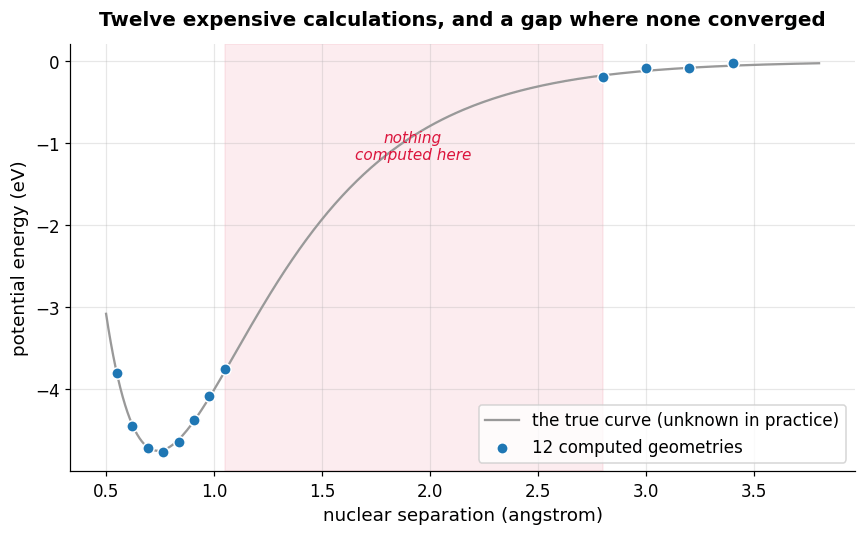

In [ ]:
well_depth, bond_length, steepness = 4.75, 0.74, 1.94       # eV and angstrom, hydrogen-like

def morse(separation):
    """Morse potential energy, in eV, for a nuclear separation in angstrom."""
    return well_depth * (1 - np.exp(-steepness * (separation - bond_length))) ** 2 - well_depth

computed_at = np.concatenate([np.linspace(0.55, 1.05, 8), np.linspace(2.8, 3.4, 4)])
noise_level = 0.02                                          # eV, the calculation's own convergence noise
energies = morse(computed_at) + rng.normal(0, noise_level, computed_at.size)
grid = np.linspace(0.5, 3.8, 300)[:, None]

plt.figure(figsize=(8, 5))
plt.plot(grid, morse(grid.ravel()), color="0.6", linewidth=1.5, label="the true curve (unknown in practice)")
plt.scatter(computed_at, energies, s=55, color="tab:blue", zorder=3, edgecolor="white",
            label="12 computed geometries")
plt.axvspan(1.05, 2.8, color="crimson", alpha=0.08)
plt.text(1.92, -1.2, "nothing\ncomputed here", ha="center", fontsize=10, color="crimson", style="italic")
plt.xlabel("nuclear separation (angstrom)")
plt.ylabel("potential energy (eV)")
plt.title("Twelve expensive calculations, and a gap where none converged")
plt.legend(loc="lower right")
plt.show()

The grey curve is drawn only so that the figures can be read; in a real calculation it is exactly
what is not known. Twelve points, a gap, and a question: what is the energy at a separation of
1.5 angstrom?

true well depth            :   4.750 eV
deepest point of the fit   :  -4.781 eV

RMSE where points were computed :   0.043 eV
RMSE inside the gap             :   0.384 eV


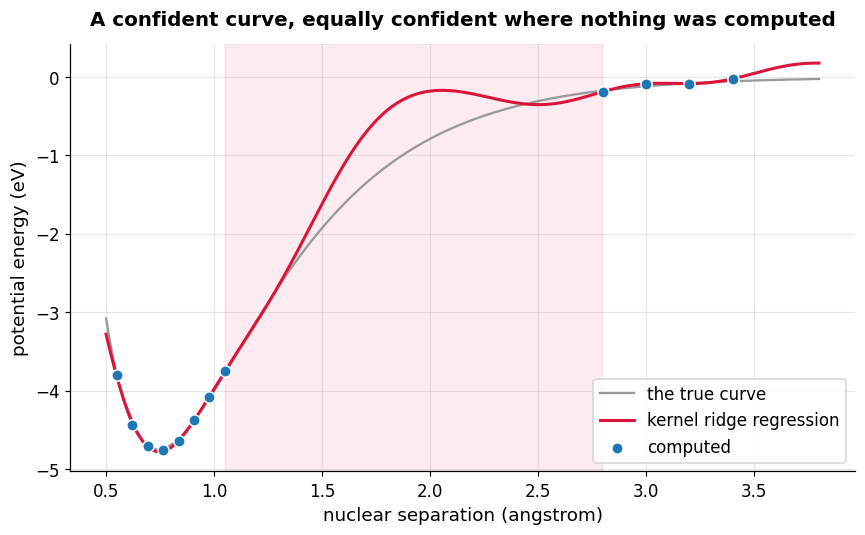

In [ ]:
length_scale = 0.35                                    # angstrom: how far the fit lets a point speak
ridge_penalty = noise_level ** 2

kernel_ridge = KernelRidge(alpha=ridge_penalty, kernel="rbf",
                           gamma=1 / (2 * length_scale ** 2)).fit(computed_at[:, None], energies)
fitted = kernel_ridge.predict(grid)

separations = grid.ravel()
truth = morse(separations)
sampled = separations < 1.1                       # where the eight calculations are
inside_gap = (separations > 1.1) & (separations < 2.8)

def rmse(where):
    """Root mean squared error of the fit against the true curve, over a region of the grid."""
    return np.sqrt(np.mean((fitted[where] - truth[where]) ** 2))

print(f"true well depth            : {-morse(bond_length):>7.3f} eV")
print(f"deepest point of the fit   : {fitted.min():>7.3f} eV")
print(f"\nRMSE where points were computed : {rmse(sampled):>7.3f} eV")
print(f"RMSE inside the gap             : {rmse(inside_gap):>7.3f} eV")

plt.figure(figsize=(8, 5))
plt.plot(grid, morse(grid.ravel()), color="0.6", linewidth=1.5, label="the true curve")
plt.plot(grid, fitted, color="crimson", linewidth=2, label="kernel ridge regression")
plt.scatter(computed_at, energies, s=55, color="tab:blue", zorder=3, edgecolor="white",
            label="computed")
plt.axvspan(1.05, 2.8, color="crimson", alpha=0.08)
plt.xlabel("nuclear separation (angstrom)")
plt.ylabel("potential energy (eV)")
plt.title("A confident curve, equally confident where nothing was computed")
plt.legend(loc="lower right")
plt.show()

Read the two errors. Where the calculations sit, the fit tracks the true curve to 0.048 eV.
Across the gap it is out by 0.398 eV — eight times worse, and on the scale of a chemical bond
rather than of a rounding error. The reason is that the RBF kernel has no information there: a sum
of bumps centred on distant points decays towards its mean, so the curve climbs out of the well
far too early.

And **the figure gives no sign of it**. A red curve is drawn across the gap with exactly the same
confidence as across the eight points at the bottom of the well.

That is the honest complaint against every regression method in this course so far. The next
section fixes it.

# 5. Gaussian processes: the same curve, with an error bar

A **Gaussian process** starts from a different idea. Instead of fitting one function, it places a
probability distribution over functions and conditions it on the data, so that what comes back is
a distribution at every input: a mean and a variance.

Two equations do all the work. With $K$ the kernel matrix of the training inputs, $\mathbf{k}_*$
the kernel values between the test point and the training points, and $\sigma_n^2$ the variance of
the measurement noise:

$$
\bar{f}_* \;=\; \mathbf{k}_*^{\top}\big(K + \sigma_n^2 I\big)^{-1}\mathbf{y} ,
\qquad\qquad
\mathbb{V}[f_*] \;=\; k(\mathbf{x}_*, \mathbf{x}_*) \;-\;
\mathbf{k}_*^{\top}\big(K + \sigma_n^2 I\big)^{-1}\mathbf{k}_*
$$

Look at the first one before reading on. Written out it is
$\bar{f}(\mathbf{x}_*) = \sum_i \alpha_i k(\mathbf{x}_i, \mathbf{x}_*)$ with
$\boldsymbol{\alpha} = (K + \sigma_n^2 I)^{-1}\mathbf{y}$: a weighted sum of kernel values, one per
training point.

## 5.1 The mean is kernel ridge regression

That is the same form as section 4, with the noise variance $\sigma_n^2$ standing exactly where
ridge regression's penalty stands. So the two should agree — not approximately, but to the
arithmetic. The cell below fits a GP with the same kernel and checks.

In [ ]:
process = GaussianProcessRegressor(kernel=RBF(length_scale=length_scale),
                                   alpha=ridge_penalty,      # sigma_n^2, where ridge puts its penalty
                                   optimizer=None).fit(computed_at[:, None], energies)
posterior_mean, posterior_sd = process.predict(grid, return_std=True)

print(f"largest difference between the GP posterior mean and kernel ridge regression: "
      f"{np.abs(posterior_mean - fitted).max():.1e} eV")

largest difference between the GP posterior mean and kernel ridge regression: 1.9e-13 eV


They are the same curve to thirteen decimal places, and that is not a numerical coincidence.
Minimising the penalised fit of section 4 gives exactly
$\hat{\boldsymbol\alpha} = (K + \sigma_n^2 I)^{-1}\mathbf{y}$ — the same coefficients the
probabilistic route produced above, with the noise variance sitting precisely where ridge
regression's penalty sits.

So a Gaussian process is not a competitor to kernel ridge regression; for the mean, it *is* kernel
ridge regression, arrived at from probability rather than from a penalty. Everything section 4
fitted, it fitted too.

The second equation is what the extra machinery buys.

## 5.2 The error bar does not depend on what you measured

Read $\mathbb{V}[f_*]$ again and notice what is missing from it: there is **no $\mathbf{y}$**. The
variance is built from the kernel between the test point and the training inputs, and nothing
else. This is a property of the Gaussian, and it is exact: the variance depends only on **where**
the measurements were taken, never on what they returned.

This is easy to mistake for a typographical accident, so the cell below fits a second process to
the same twelve geometries with the energies **replaced by random numbers**, and compares the two
error bars.

In [ ]:
nonsense = rng.normal(0, 3, energies.size)                   # not energies at all
other_process = GaussianProcessRegressor(kernel=RBF(length_scale=length_scale),
                                         alpha=ridge_penalty,
                                         optimizer=None).fit(computed_at[:, None], nonsense)
other_mean, sd_from_nonsense = other_process.predict(grid, return_std=True)

print(f"the two predicted curves differ by up to     : {np.abs(posterior_mean - other_mean).max():>8.3f} eV")
print(f"the two sets of error bars differ by up to   : {np.abs(posterior_sd - sd_from_nonsense).max():>8.1e} eV")

the two predicted curves differ by up to     :   24.077 eV
the two sets of error bars differ by up to   :  0.0e+00 eV


Not small — **exactly zero**. The two models predict entirely different curves and report
identical uncertainty, because the uncertainty answers a different question: not *"how surprising
were the measurements?"* but *"how far is this point from the places I have measured?"*

That is a strength and a limitation in one sentence, and both matter in practice.

- It is a **strength** because the error bar is available before a single measurement is taken. You
  can plan where to put the twelve calculations by computing the variance on a grid of candidate
  geometries and never running any of them.
- It is a **limitation** because the error bar cannot notice that your model is wrong. The
  expression subtracts from the prior covariance a term for what the measurements told you —
  but the prior is your own choice of kernel and noise level, and a confidently wrong kernel gives
  confidently narrow bars.

One qualification, because it is easy to over-state the result. The variance ignores $\mathbf{y}$
**at a fixed kernel**, which is what the cell above fitted (`optimizer=None` holds the length scale
where it was put). In normal use the kernel's own parameters are chosen by maximising the marginal
likelihood, which *does* depend on $\mathbf{y}$ — so the data
re-enters through the back door, by setting the length scale. The equation is exact; "a GP's error
bars never look at
the data" is not.

## 5.3 Where to compute next

at 0.80 angstrom:  predicted  -4.731 eV   +/- 0.012 eV   (true value  -4.693 eV)
at 1.95 angstrom:  predicted  -0.210 eV   +/- 0.985 eV   (true value  -0.865 eV)
at 3.10 angstrom:  predicted  -0.081 eV   +/- 0.021 eV   (true value  -0.097 eV)


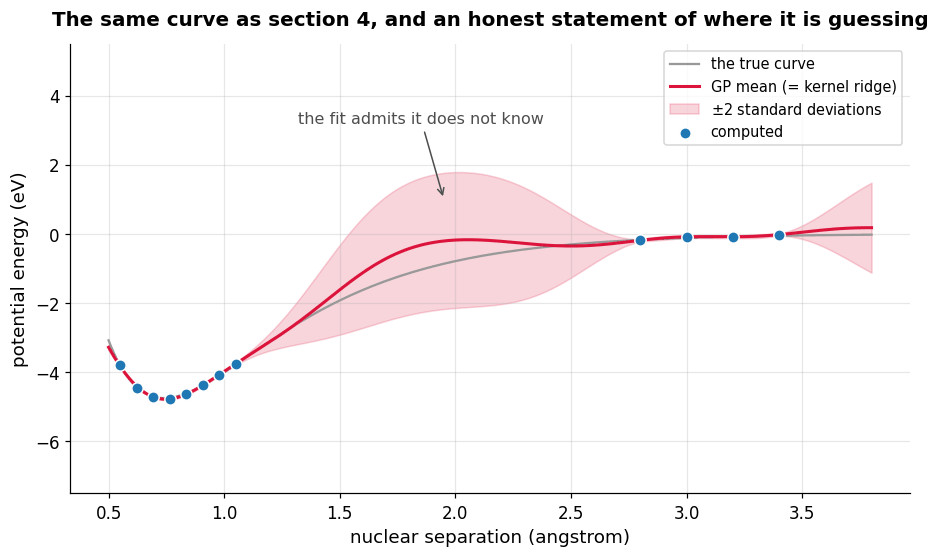

In [ ]:
for separation in [0.80, 1.95, 3.10]:
    nearest = np.abs(grid.ravel() - separation).argmin()
    print(f"at {separation:.2f} angstrom:  predicted {posterior_mean[nearest]:>7.3f} eV"
          f"   +/- {posterior_sd[nearest]:.3f} eV"
          f"   (true value {morse(separation):>7.3f} eV)")

plt.figure(figsize=(8.5, 5.2))
plt.plot(grid, morse(grid.ravel()), color="0.6", linewidth=1.5, label="the true curve")
plt.plot(grid, posterior_mean, color="crimson", linewidth=2, label="GP mean (= kernel ridge)")
plt.fill_between(grid.ravel(), posterior_mean - 2 * posterior_sd, posterior_mean + 2 * posterior_sd,
                 color="crimson", alpha=0.18, label="$\\pm 2$ standard deviations")
plt.scatter(computed_at, energies, s=55, color="tab:blue", zorder=3, edgecolor="white",
            label="computed")
plt.annotate("the fit admits it does not know", xy=(1.95, 1.0), xytext=(1.85, 3.2),
             fontsize=10.5, color="0.3", ha="center",
             arrowprops={"arrowstyle": "->", "color": "0.3"})
plt.xlabel("nuclear separation (angstrom)")
plt.ylabel("potential energy (eV)")
plt.title("The same curve as section 4, and an honest statement of where it is guessing")
plt.legend(loc="upper right", fontsize=9.5)
plt.ylim(-7.5, 5.5)
plt.show()

The error bar is 0.012 eV at 0.80 angstrom, where the calculations are packed within a tenth of an
angstrom of each other, and 0.985 eV in the middle of the gap — more than eighty times larger.
That width is doing real work: at 1.95 angstrom the fit predicts $-0.191$ eV where the truth is
$-0.865$ eV, and the $\pm 2$ standard deviation band is wide enough to contain the true curve that
section 4's red line missed in silence. Out at 3.10 angstrom, back among computed points, the bar
collapses to 0.021 eV.

That number is the product. An experimentalist with a fixed budget of measurements, or a
computational chemist with a fixed budget of CPU hours, reads the widest part of the band and puts
the next one there. Done repeatedly, that loop is **Bayesian optimisation**: its acquisition
functions send the next measurement where the model's uncertainty is large, or where its prediction
is promising, or both. This is old and settled practice: it is how expensive computer experiments
have been designed since the late 1980s, and it is where Gaussian processes have always been most
at home.

> A model that reports where it is ignorant is worth more than a slightly more accurate model that
> does not. This is the one place in the course where the uncertainty attaches to the individual
> prediction rather than to the score — map step 9.2.

# 6. What a kernel costs

Every equation in this notebook contains $K$, the matrix of kernel values between **every pair**
of training samples. That matrix has $n^2$ entries and the solutions invert it, so the cost grows
steeply with the sample size. `05A` §3.4 already flagged this for the SVM; the cell below measures
it.

In [ ]:
print(f"{'training events':>17}{'fit seconds':>14}")
timings = []
for size in [1000, 2000, 4000, 8000, 14265]:
    machine = make_pipeline(StandardScaler(), SVC(C=10))
    start = time.time()
    machine.fit(X_train[:size], y_train[:size])
    timings.append(time.time() - start)
    print(f"{size:>17}{timings[-1]:>14.2f}")

growth = np.log(timings[-1] / timings[0]) / np.log(14265 / 1000)
print(f"\nover this range the time grows like n^{growth:.1f}")

  training events   fit seconds


             1000          0.03


             2000          0.05


             4000          0.14


             8000          0.53


            14265          1.56

over this range the time grows like n^1.5


Fourteen times the data, and far more than fourteen times the work. The cost is well understood:
$O(n^3)$ for the matrix inversion and $O(n^2)$ merely to hold $K$ in memory. Past roughly ten
thousand points an exact Gaussian process stops being practical on an ordinary machine, and `SVC`
carries the same warning in its own documentation — its fit time grows at least quadratically with
the sample size, and it is not the tool for hundreds of thousands of events. The twelve-point
example of section 5 is
therefore typical of where GPs are actually used, not a toy reduction of a big problem.

The standard remedy is to approximate the kernel by an explicit, modest set of features and then
use a *linear* method on them, which is back to `05A`'s cost. scikit-learn ships two:
`Nystroem`, which builds features from a random subset of the training samples, and `RBFSampler`,
which draws random Fourier features instead.

In [ ]:
print(f"{'':44}{'cross-validated ROC AUC':>26}")
for label, machine in [
        ("exact RBF kernel, C = 10", make_pipeline(StandardScaler(), SVC(C=10))),
        ("Nystroem, 300 features, then a linear SVM",
         make_pipeline(StandardScaler(), Nystroem(gamma=0.1, n_components=300, random_state=0),
                       LinearSVC(C=10))),
        ("RBFSampler, 300 features, then a linear SVM",
         make_pipeline(StandardScaler(), RBFSampler(gamma=0.1, n_components=300, random_state=0),
                       LinearSVC(C=10)))]:
    scores = cross_val_score(machine, X_train, y_train, cv=folds, scoring="roc_auc", n_jobs=-1)
    print(f"{label:44}{scores.mean():>20.4f} +/- {scores.std():.4f}")

                                               cross-validated ROC AUC


exact RBF kernel, C = 10                                  0.9236 +/- 0.0049


Nystroem, 300 features, then a linear SVM                 0.9241 +/- 0.0052


RBFSampler, 300 features, then a linear SVM               0.9185 +/- 0.0051


300 explicit features reproduce the exact kernel's 0.9236 — `Nystroem` at 0.9241 and `RBFSampler`
at 0.9185 — on a model whose cost is now linear in the number of events. On this dataset the
approximation costs nothing measurable; the point of the comparison is that it is available when
$n$ makes the exact kernel impossible.

# 7. The closing procedure, on a kernel SVM

The seven steps are the same as `03C` §8, `04A` §13, `04B` §12, `04C` §12 and `05A` §7, and this
time only step 4 changes: the grid has two hyperparameters in it rather than one, because section
3.2 showed that $\gamma$ and `C` both control flexibility.

In [ ]:
# 1 (map step 2) — the split made in section 3.2, before anything was looked at.
# 2 (map step 5) — a pipeline, with the scaler inside it: section 3.4.
# 3 (map step 6) — the baseline to beat is 05A's linear SVM, at 0.8328.
# 4 (map step 8) — cross-validate over BOTH dials, on the training part only.
search = GridSearchCV(make_pipeline(StandardScaler(), SVC()),
                      {"svc__gamma": [0.01, 0.1, 0.3], "svc__C": [1, 10, 100]},
                      scoring="roc_auc", cv=folds, n_jobs=-1)
search.fit(X_train, y_train)

# 5 (map step 9) — the test set, once.
test_scores = search.best_estimator_.decision_function(X_test)
test_auc = roc_auc_score(y_test, test_scores)

# 6 (map step 9.2) — an uncertainty on that number, by bootstrapping the test set.
boot = np.array([roc_auc_score(y_test.to_numpy()[idx], test_scores[idx])
                 for idx in (rng.integers(0, len(y_test), len(y_test)) for _ in range(400))])

# 7 (map step 10) — report it with its limits.
print(f"chosen gamma / C          : {search.best_params_['svc__gamma']} / {search.best_params_['svc__C']}")
print(f"cross-validated ROC AUC   : {search.best_score_:.4f}")
print(f"test ROC AUC              : {test_auc:.4f}   95% bootstrap "
      f"[{np.percentile(boot, 2.5):.4f}, {np.percentile(boot, 97.5):.4f}]")
print(f"baseline, linear SVM (05A): 0.8328")
print(f"\nthe whole grid, as cross-validation saw it:")
order = np.argsort(-search.cv_results_["mean_test_score"])
for i in order:
    p = search.cv_results_["params"][i]
    print(f"   gamma {p['svc__gamma']:<5} C {p['svc__C']:<5} "
          f"ROC AUC {search.cv_results_['mean_test_score'][i]:.4f} "
          f"+/- {search.cv_results_['std_test_score'][i]:.4f}")

chosen gamma / C          : 0.1 / 100
cross-validated ROC AUC   : 0.9246
test ROC AUC              : 0.9259   95% bootstrap [0.9172, 0.9351]
baseline, linear SVM (05A): 0.8328

the whole grid, as cross-validation saw it:
   gamma 0.1   C 100   ROC AUC 0.9246 +/- 0.0050
   gamma 0.1   C 10    ROC AUC 0.9236 +/- 0.0049
   gamma 0.3   C 10    ROC AUC 0.9199 +/- 0.0037
   gamma 0.3   C 1     ROC AUC 0.9191 +/- 0.0039
   gamma 0.1   C 1     ROC AUC 0.9154 +/- 0.0041
   gamma 0.01  C 100   ROC AUC 0.9140 +/- 0.0042
   gamma 0.3   C 100   ROC AUC 0.9108 +/- 0.0039
   gamma 0.01  C 10    ROC AUC 0.9069 +/- 0.0040
   gamma 0.01  C 1     ROC AUC 0.8949 +/- 0.0036


Read the grid, not only the winner. The scores are close across a broad region and fall away at
the corners, which is the usual shape and the reason a two-dimensional search is worth its cost
here where `05A`'s one-dimensional sweep over `C` was flat.

The reported number carries the same limits as every other in the course: it is an ROC AUC on
*these* simulated showers, from a single test split, and the bootstrap interval measures only the
test set's size — not the simulation's fidelity to a real telescope, which `05A` §6 raised and no
resampling can address.

# 8. Common pitfalls

**Leaving the features unscaled.** The RBF kernel is a distance in disguise, and section 3.4 lost
0.04 of ROC AUC to a missing `StandardScaler` with no error and no warning.

**Tuning $\gamma$ on the training score.** It rises monotonically to 1.0000 and means nothing
(section 3.2). Only the cross-validated column turns around, and it turns around well before the
training score flattens.

**Tuning $\gamma$ and `C` separately.** They both control flexibility and they interact, so a
sweep over one at a fixed value of the other can miss the good region entirely. Section 7 searches
the pair.

**Reading a kernel ridge curve as though it were supported everywhere.** Section 4 drew a
confident line through a region containing no data. Nothing in the output distinguished it from
the part of the curve that was fitted.

**Reading a Gaussian process error bar as a test of the model.** It does not depend on the
measured values at all (section 5.2), so it cannot tell you the kernel was a poor choice. It
reports distance from your measurements, nothing more.

**Reaching for an exact kernel on a large sample.** The fit grew faster than $n^2$ in section 6.
Past a few tens of thousands of samples, use `Nystroem` or `RBFSampler`, or a different family.

**Expecting a kernel to cope with irrelevant features.** This is the family's most firmly
 established weakness, and the early
claim that kernels finesse the curse of dimensionality is simply false. Add six columns of pure
noise to a four-feature problem and a degree-2 polynomial SVM's error moves from 0.078 to 0.152,
while methods able to concentrate on a subspace barely move. The reason is the one `05A` §1
gave: the kernel is a distance over *all* the features, and it cannot decide to look at a subspace.
`05A` §4.2 measured the same effect on nearest neighbours, and it is why the optional notebook `X1`
lists distance-based models as the ones for which feature selection matters most.

**Treating the kernel as a universal upgrade.** On the telescope events it bought 0.09 of ROC AUC;
broad benchmarks still put random forests ahead of RBF SVMs on average, and `04A` §11.1's advantage
— a tree needs no scaling and takes mixed feature types
as they come — is untouched by any of this.

# 9. Final exercises

<div class="alert alert-success">
<b>Exercise 1 — The degree-3 kernel</b><br>
Section 2.1 verified $\boldsymbol{\phi}(\mathbf{x}) \cdot \boldsymbol{\phi}(\mathbf{x}') = (1 +
\mathbf{x}\cdot\mathbf{x}')^2$ for two features.
<br><br>
1. How many terms does a degree-3 polynomial expansion of two features have? Write them out.<br>
2. Use <code>sklearn.preprocessing.PolynomialFeatures(degree=3)</code> to build the expansion for two
random samples, and take the dot product of the results.<br>
3. Compare it with $(1 + \mathbf{x}\cdot\mathbf{x}')^3$. They will <em>not</em> be equal. Look at the
coefficients in section 2.1's <code>expansion</code> and work out what <code>PolynomialFeatures</code>
would have to multiply each term by for them to agree.<br>
4. What does this tell you about which expansion a polynomial kernel actually corresponds to?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 2 — How far does a training point reach?</b><br>
Section 2.3 said that $\gamma$ sets the reach of each training sample.
<br><br>
1. Fit <code>SVC(gamma=g)</code> to the rings of section 1 for $g$ = 0.1, 1, 10 and 100.<br>
2. For each, draw the decision boundary over the mesh as section 3.1 does.<br>
3. Report the number of support vectors in each case, and the training accuracy.<br>
4. At $g = 100$ the training accuracy is excellent and the boundary is a collection of islands.
Explain what the model has learned, in terms of the figure in section 2.3, and say which value of
$k$ in <code>05A</code> section 2.2 it resembles.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 3 — Where would you compute next?</b><br>
Section 5.3 read the error bar off a Gaussian process fitted to twelve geometries.
<br><br>
1. Refit the process of section 5 using only the <em>eight</em> points below 1.1 angstrom.<br>
2. Plot the mean and the $\pm 2$ standard deviation band over the same grid. Where is the band
widest now?<br>
3. Add one calculation at the separation where the band is widest, refit, and report how much the
widest band has narrowed.<br>
4. Repeat step 3 twice more. Then answer: would choosing the three extra geometries on an evenly
spaced grid have done better or worse, and how would you decide that fairly?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 4 — Is the kernel worth it on your own data?</b><br>
Take any dataset from an earlier notebook with continuous features — the California housing data of
<code>04C</code> section 5, or the diabetes cohort of <code>02A</code> section 8.
<br><br>
1. Cross-validate a <code>Ridge</code> model and a <code>KernelRidge(kernel="rbf")</code> on it, both
inside a <code>StandardScaler</code>, tuning <code>alpha</code> and <code>gamma</code>.<br>
2. Record the fit time of each.<br>
3. Compare both with the gradient boosting result the earlier notebook reported.<br>
4. On the evidence of your three numbers, and of section 6's timings, when would you choose the
kernel method for this dataset? Give a condition, not a preference.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# Key Takeaways

- **A model is only as good as its basis.** Powers of the input fitted the ringing spring to
  0.083 cm, but only at degree 13 — degree 9 was three times worse and degree 19 twenty-six times
  worse, and every power is non-zero everywhere, so a bad choice ruins the fit across the whole
  domain.
- **Putting one basis function at each measurement** removes the choice. It fitted the same curve
  to 0.090 cm with no search for a magic degree, and to 0.387 cm across the empty ends of the
  domain where the best polynomial managed 0.685.
- **That basis has as many coefficients as measurements**, so it interpolates: with no penalty it
  missed the truth by 3683 cm using weights of order $10^{15}$.
- **The penalty is $\mathbf{a}^\top K\mathbf{a}$, not $\sum_i a_i^2$**, because the basis functions
  are not orthonormal and $K$ is their matrix of inner products. With narrow bumps the two agree
  (0.082 against 0.079); with bumps wider than the signal the naive one is five times worse (0.111
  against 0.594).
- The **kernel trick** replaces every dot product between samples by a kernel. For the degree-2
  polynomial kernel, $(1 + \mathbf{x}\cdot\mathbf{x}')^2$ and the dot product of two explicit
  six-dimensional expansions agree to machine precision — one of them builds the expansion and the
  other never does.
- A valid kernel is **symmetric and positive semi-definite**; those are exactly the functions that
  correspond to a dot product in some feature space.
- The **RBF kernel** $\exp(-\gamma\lVert\mathbf{x}-\mathbf{x}'\rVert^2)$ turns `05A`'s distance
  into a similarity. On the rings it scored 0.987 against 0.550 for the same machine with a linear
  kernel, with no expansion built and nothing said about circles.
- $\gamma$ is a **flexibility dial** and it overfits hard: on 4,000 telescope events the training
  ROC AUC climbed to 1.0000 while the cross-validated score peaked at 0.9105 and fell to 0.8142.
- On the full telescope data the kernel moved the SVM from **0.8328 to 0.9236**, past nearest
  neighbours and within 0.012 of the random forest — `04A` §11.2's promise, and confirmation that
  `05A`'s diagnosis of a wrong-shaped boundary was right.
- **A kernel built from a distance needs scaled features**: 0.8835 raw against 0.9236 standardised,
  with no warning in between.
- **Kernel ridge regression** is the same substitution applied to `03C`'s ridge. On the Morse curve
  it tracked the truth to 0.048 eV where calculations existed and was out by 0.398 eV across the
  gap, with nothing in the figure to distinguish the two.
- **A Gaussian process posterior mean *is* kernel ridge regression** — the two agreed to
  $10^{-13}$ eV — with the noise variance $\sigma_n^2$ standing where the ridge penalty stands.
- **The GP's error bar does not depend on the measured values.** Replacing the energies with random
  numbers changed it by exactly zero. It reports distance from your measurements: 0.012 eV among
  the computed points, 0.985 eV in the middle of the gap.
- Kernels cost $O(n^2)$ memory and up to $O(n^3)$ time. `Nystroem` with 300 features reproduced the
  exact kernel's 0.9236 at 0.9241, on a model that is linear in $n$.

# Optional preparation for the next notebook

Before `05C`, students should be comfortable with:

- the RBF kernel as a **neighbourhood**: samples within roughly $1/\sqrt{\gamma}$ of each other are
  similar, and everything beyond that is effectively invisible;
- the Euclidean distance and the need to scale before using one (`05A` §1, section 3.4 here);
- reading a two-dimensional scatter plot of labelled points, as in section 1.

`05C` keeps the distance and throws away the labels. **Clustering** asks what structure the samples
have when nothing says which class they belong to — $k$-means, hierarchical clustering, and DBSCAN,
which grows a cluster by joining samples that lie within a radius $\varepsilon$ of one another.
That $\varepsilon$-ball and this notebook's RBF kernel are the same neighbourhood idea used for two
different purposes, which is why Class 5 is one hour of supervised learning from distances followed
by one hour of unsupervised learning from the same distances.